# Image classification
## Human Pose Classification

In [1]:
import warnings
warnings.filterwarnings('ignore')


In [2]:
from datasets import load_dataset

dataset = load_dataset("Bingsu/Human_Action_Recognition", split='train')

Generating test split: 100%|██████████| 5400/5400 [00:00<00:00, 77831.11 examples/s]


In [3]:
dataset = dataset.shuffle().train_test_split(test_size=0.2)

In [4]:
dataset['train'][0]

{'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=276x183>,
 'labels': 5}

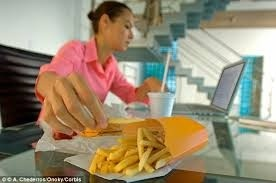

In [5]:
dataset['train'][0]['image']

In [6]:
labels = dataset['train'].features['labels'].names

label2id, id2label = dict(), dict()

for i, label in enumerate(labels):
    label2id[label] = i
    id2label[i] = label

print(label2id)
print(id2label)

{'calling': 0, 'clapping': 1, 'cycling': 2, 'dancing': 3, 'drinking': 4, 'eating': 5, 'fighting': 6, 'hugging': 7, 'laughing': 8, 'listening_to_music': 9, 'running': 10, 'sitting': 11, 'sleeping': 12, 'texting': 13, 'using_laptop': 14}
{0: 'calling', 1: 'clapping', 2: 'cycling', 3: 'dancing', 4: 'drinking', 5: 'eating', 6: 'fighting', 7: 'hugging', 8: 'laughing', 9: 'listening_to_music', 10: 'running', 11: 'sitting', 12: 'sleeping', 13: 'texting', 14: 'using_laptop'}


## Image Preprocessing

In [7]:
from transformers import AutoImageProcessor #-> like Tokenizer

model_ckpt = "google/vit-base-patch16-224-in21k"
# model_ckpt = "microsoft/swinv2-tiny-patch4-window16-256"

In [8]:
from torchvision.transforms import RandomResizedCrop, Compose, Normalize, ToTensor

image_processor = AutoImageProcessor.from_pretrained(model_ckpt, use_fast=True)
normalize = Normalize(mean=image_processor.image_mean, std=image_processor.image_std)

size = (image_processor.size['shortest_edge'] if 'shortest_edge' in image_processor.size 
        else (image_processor.size['height'], image_processor.size['width']))

_transforms = Compose([RandomResizedCrop(size), ToTensor(), normalize])

def transforms(batch):
    batch['pixel_values'] = [_transforms(img.convert('RGB')) for img in batch['image']]

    del batch['image']

    return batch

In [9]:
dataset = dataset.with_transform(transforms)

## Evaluate the model


In [10]:
# !pip install evaluate

import evaluate
import numpy as np

accuracy = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    return accuracy.compute(predictions=predictions, references=labels)

## Vision Transformer (ViT) Fine Tuning for Image Classification

In [11]:
from transformers import AutoModelForImageClassification
import torch

In [12]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

model = AutoModelForImageClassification.from_pretrained(
    model_ckpt,
    num_labels = len(labels),
    id2label = id2label,
    label2id = label2id
).to(device)

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 2153.54it/s, Materializing param=vit.layernorm.weight]                                 
ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.weight | UNEXPECTED | 
pooler.dense.bias   | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [13]:
len(labels)

15

## Model Training

In [15]:
from transformers import TrainingArguments, Trainer


args = TrainingArguments(
    output_dir="train_dir",
    remove_unused_columns=False,
    eval_strategy='epoch',
    save_strategy='epoch',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=5,
    load_best_model_at_end=True,
    metric_for_best_model='accuracy'
)


trainer = Trainer(
    model = model,
    args=args,
    train_dataset=dataset['train'],
    eval_dataset=dataset['test'],
    processing_class=image_processor, # <--- Changed from 'tokenizer' to 'processing_class'
    compute_metrics=compute_metrics
)

In [17]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy
1,0.791836,0.854316,0.763889
2,0.700691,0.796871,0.768254
3,0.636202,0.792828,0.771429
4,0.571213,0.751492,0.777778
5,0.544789,0.721302,0.796032


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  3.92it/s]


TrainOutput(global_step=3150, training_loss=0.6373611135331411, metrics={'train_runtime': 1468.75, 'train_samples_per_second': 34.315, 'train_steps_per_second': 2.145, 'total_flos': 3.906051336688435e+18, 'train_loss': 0.6373611135331411, 'epoch': 5.0})

In [18]:
trainer.evaluate()

{'eval_loss': 0.72882080078125,
 'eval_accuracy': 0.7880952380952381,
 'eval_runtime': 22.5433,
 'eval_samples_per_second': 111.785,
 'eval_steps_per_second': 7.009,
 'epoch': 5.0}

In [19]:
trainer.save_model('vit-human-pose-classification')

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.18it/s]


## Classification Report and Confusion Matrix

In [20]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
logits = trainer.predict(dataset['test'])

In [22]:
logits = logits.predictions

In [23]:
y_pred = np.argmax(logits, axis=1)

In [24]:
y_true = [x['labels'] for x in dataset['test']]

In [25]:
print(classification_report(y_true, y_pred, target_names=labels))

                    precision    recall  f1-score   support

           calling       0.65      0.75      0.69       157
          clapping       0.84      0.81      0.83       168
           cycling       0.93      0.93      0.93       169
           dancing       0.86      0.77      0.81       157
          drinking       0.86      0.78      0.82       180
            eating       0.90      0.85      0.87       163
          fighting       0.82      0.85      0.84       186
           hugging       0.83      0.79      0.81       145
          laughing       0.78      0.81      0.80       182
listening_to_music       0.76      0.73      0.75       162
           running       0.81      0.86      0.84       168
           sitting       0.65      0.74      0.69       185
          sleeping       0.86      0.86      0.86       158
           texting       0.60      0.64      0.62       159
      using_laptop       0.80      0.72      0.76       181

          accuracy                    

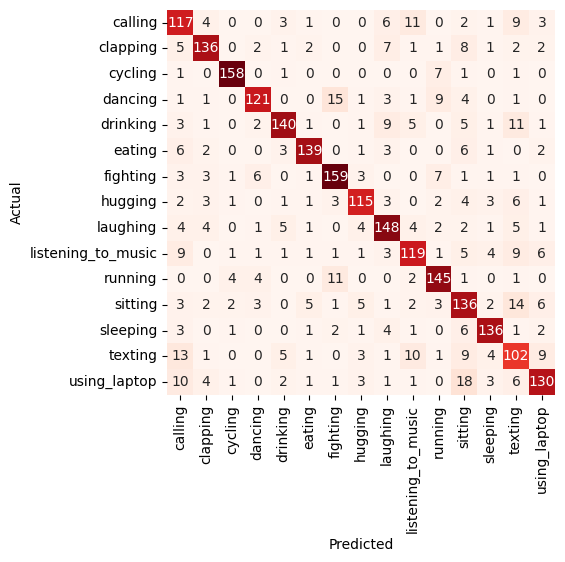

In [26]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, xticklabels=label2id.keys(), yticklabels=label2id.keys(), fmt='d', cbar=False, cmap='Reds')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Prediction on Real Image

In [ ]:
from transformers import pipeline
from transformers import AutoImageProcessor

model_ckpt = "google/vit-base-patch16-224-in21k"
image_processor = AutoImageProcessor.from_pretrained(model_ckpt, use_fast=True)

pipe = pipeline('image-classification', model='vit-human-pose-classification', 
                image_processor=image_processor)
# An image of sleeping man - replace it with your preferable test image
url = "https://images.pexels.com/photos/3771069/pexels-photo-3771069.jpeg"

output = pipe(url)
output

Loading weights: 100%|██████████| 200/200 [00:00<00:00, 1972.50it/s, Materializing param=vit.layernorm.weight]                                 


[{'label': 'sleeping', 'score': 0.9233629107475281},
 {'label': 'hugging', 'score': 0.010953755117952824},
 {'label': 'listening_to_music', 'score': 0.008649393916130066},
 {'label': 'laughing', 'score': 0.007384873926639557},
 {'label': 'texting', 'score': 0.006210973486304283}]

In [28]:
image_processor.save_pretrained('vit-human-pose-classification')

['vit-human-pose-classification/preprocessor_config.json']

In [ ]:
# Load the model and image processor from the local directory
from transformers import AutoImageProcessor, AutoModel

local_directory = 'vit-human-pose-classification'
image_processor = AutoImageProcessor.from_pretrained(local_directory, use_fast=True)
model = AutoModel.from_pretrained(local_directory, local_files_only=True)

Loading weights: 100%|██████████| 198/198 [00:00<00:00, 1652.10it/s, Materializing param=layernorm.weight]                                 
ViTModel LOAD REPORT from: vit-human-pose-classification
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Push Model to Azure Blob Storage

In [ ]:
# Install Azure Blob SDK if not already installed
!pip install azure-storage-blob python-dotenv

In [ ]:
import os
from azure.storage.blob import BlobServiceClient
from dotenv import load_dotenv

load_dotenv()

model_name = 'vit-human-pose-classification'
model_save_dir = 'vit-human-pose-classification'  # local directory where model was saved

connection_string = os.environ['AZURE_STORAGE_CONNECTION_STRING']
container_name = os.environ.get('AZURE_STORAGE_CONTAINER_NAME', 'models')

blob_service_client = BlobServiceClient.from_connection_string(connection_string)
container_client = blob_service_client.get_container_client(container_name)

# Create container if it doesn't exist
try:
    container_client.create_container()
    print(f'Container {container_name!r} created.')
except Exception:
    print(f'Container {container_name!r} already exists.')

# Upload all model files
for root, _, files in os.walk(model_save_dir):
    for file in files:
        local_path = os.path.join(root, file)
        blob_name = f"{model_name}/{os.path.relpath(local_path, model_save_dir)}"
        with open(local_path, 'rb') as data:
            container_client.upload_blob(blob_name, data, overwrite=True)
        print(f'Uploaded: {blob_name}')

print('\nAll model files uploaded successfully.')

In [ ]:
# List uploaded blobs to verify
print(f'Blobs in container {container_name!r} with prefix {model_name!r}:')
for blob in container_client.list_blobs(name_starts_with=model_name):
    print(f'  {blob.name}')